# Mutual Fund Performance Analytics

This notebook computes daily returns, CAGR, Risk metrics (Sharpe, Sortino, Max Drawdown), Alpha, Beta, Tracking Error, and generates a composite scorecard for 40 mutual fund schemes.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Load Data from SQLite Database

In [2]:
print("1. Connecting to DB and loading data...")
conn = sqlite3.connect('bluestock_mf.db')

dim_fund = pd.read_sql_query("SELECT * FROM dim_fund", conn)
fact_nav = pd.read_sql_query("SELECT * FROM fact_nav", conn)
conn.close()

fact_nav['date'] = pd.to_datetime(fact_nav['date'])
fact_nav = fact_nav.sort_values(by=['amfi_code', 'date'])
print(f"Loaded {len(dim_fund)} funds and {len(fact_nav)} NAV records.")

1. Connecting to DB and loading data...
Loaded 40 funds and 64320 NAV records.


## 2. Compute Daily Returns & Validate Distribution

2. Computing Daily Returns...


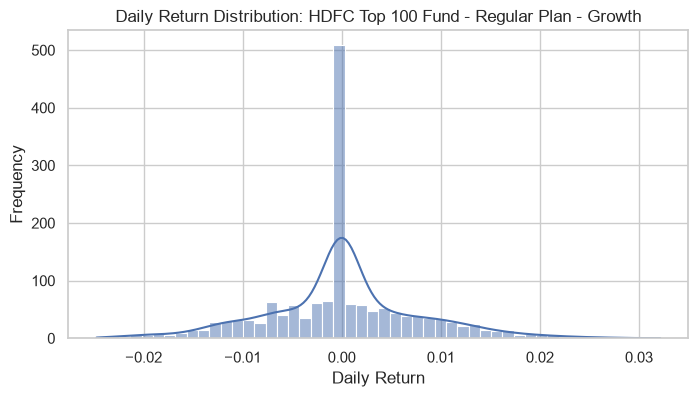

In [3]:
print("2. Computing Daily Returns...")
fact_nav['daily_return'] = fact_nav.groupby('amfi_code')['nav'].pct_change()

# Plot distribution for a sample fund
sample_code = fact_nav['amfi_code'].iloc[0]
sample_name = dim_fund[dim_fund['amfi_code'] == sample_code]['scheme_name'].values[0]

plt.figure(figsize=(8, 4))
sns.histplot(fact_nav[fact_nav['amfi_code'] == sample_code]['daily_return'].dropna(), bins=50, kde=True)
plt.title(f"Daily Return Distribution: {sample_name}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## 3. Fetch Benchmark Data from Yahoo Finance

In [4]:
print("3. Fetching Benchmark Data...")
start_date = fact_nav['date'].min()
end_date = fact_nav['date'].max()

nifty_data = yf.download(["^NSEI", "^CNX100"], start=start_date, end=end_date + pd.Timedelta(days=1))
if isinstance(nifty_data.columns, pd.MultiIndex):
    nifty_close = nifty_data['Close']
else:
    nifty_close = pd.DataFrame({
        '^NSEI': yf.download("^NSEI", start=start_date, end=end_date)['Close'],
        '^CNX100': yf.download("^CNX100", start=start_date, end=end_date)['Close']
    })

nifty_close.index = pd.to_datetime(nifty_close.index)
nifty_close.index = nifty_close.index.tz_localize(None)

nifty_returns = nifty_close.pct_change().reset_index()
nifty_returns = nifty_returns.rename(columns={'Date': 'date', '^NSEI': 'nifty50_return', '^CNX100': 'nifty100_return'})
print("Benchmark data fetched successfully.")

3. Fetching Benchmark Data...


[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

Benchmark data fetched successfully.


## 4. Calculate Risk & Return Metrics for each fund

In [5]:
print("4. Calculating Risk & Return Metrics...")
results = []
rf = 0.065 # 6.5% Risk free rate

max_date = end_date
date_1yr = max_date - pd.DateOffset(years=1)
date_3yr = max_date - pd.DateOffset(years=3)
date_5yr = max_date - pd.DateOffset(years=5)

for amfi_code in fact_nav['amfi_code'].unique():
    fund_data = fact_nav[fact_nav['amfi_code'] == amfi_code].copy()
    if len(fund_data) == 0:
        continue
        
    nav_end = fund_data.iloc[-1]['nav']
    
    def get_nav_at_date(target_date):
        past_data = fund_data[fund_data['date'] <= target_date]
        if len(past_data) > 0:
            return past_data.iloc[-1]['nav']
        return np.nan
        
    nav_1yr = get_nav_at_date(date_1yr)
    nav_3yr = get_nav_at_date(date_3yr)
    nav_5yr = get_nav_at_date(date_5yr)
    
    cagr_1yr = (nav_end / nav_1yr) - 1 if not pd.isna(nav_1yr) else np.nan
    cagr_3yr = (nav_end / nav_3yr)**(1/3) - 1 if not pd.isna(nav_3yr) else np.nan
    cagr_5yr = (nav_end / nav_5yr)**(1/5) - 1 if not pd.isna(nav_5yr) else np.nan
    
    # Sharpe Ratio
    daily_returns = fund_data['daily_return'].dropna()
    ann_return = daily_returns.mean() * 252
    ann_std = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_std if ann_std > 0 else np.nan
    
    # Sortino Ratio
    neg_returns = daily_returns[daily_returns < 0]
    downside_std = neg_returns.std() * np.sqrt(252)
    sortino = (ann_return - rf) / downside_std if downside_std > 0 else np.nan
    
    # Max Drawdown
    fund_data['running_max'] = fund_data['nav'].cummax()
    fund_data['drawdown'] = (fund_data['nav'] / fund_data['running_max']) - 1
    max_dd = fund_data['drawdown'].min()
    
    # Alpha, Beta, Tracking Error
    merged = pd.merge(fund_data, nifty_returns, on='date', how='inner').dropna(subset=['daily_return', 'nifty100_return', 'nifty50_return'])
    
    if len(merged) > 30:
        slope, intercept, r_value, p_value, std_err = linregress(merged['nifty100_return'], merged['daily_return'])
        beta = slope
        alpha = intercept * 252
        tracking_error = (merged['daily_return'] - merged['nifty100_return']).std() * np.sqrt(252)
    else:
        alpha, beta, tracking_error = np.nan, np.nan, np.nan
        
    results.append({
        'amfi_code': amfi_code,
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'max_drawdown': max_dd,
        'alpha': alpha,
        'beta': beta,
        'tracking_error': tracking_error
    })

metrics_df = pd.DataFrame(results)
print("Metrics calculated.")

4. Calculating Risk & Return Metrics...
Metrics calculated.


## 5. Build Fund Scorecard

In [6]:
print("5. Merging with Fund Master and Building Scorecard...")
fund_metrics = pd.merge(dim_fund, metrics_df, on='amfi_code', how='inner')

fund_metrics['return_3yr_rank'] = fund_metrics['cagr_3yr'].rank(ascending=False)
fund_metrics['sharpe_rank'] = fund_metrics['sharpe_ratio'].rank(ascending=False)
fund_metrics['alpha_rank'] = fund_metrics['alpha'].rank(ascending=False)
fund_metrics['expense_rank'] = fund_metrics['expense_ratio_pct'].rank(ascending=True)
fund_metrics['max_dd_rank'] = fund_metrics['max_drawdown'].rank(ascending=False)

n_funds = len(fund_metrics)
def rank_to_score(rank):
    return (n_funds - rank) / (n_funds - 1) * 100

fund_metrics['score_3yr'] = rank_to_score(fund_metrics['return_3yr_rank'])
fund_metrics['score_sharpe'] = rank_to_score(fund_metrics['sharpe_rank'])
fund_metrics['score_alpha'] = rank_to_score(fund_metrics['alpha_rank'])
fund_metrics['score_expense'] = rank_to_score(fund_metrics['expense_rank'])
fund_metrics['score_max_dd'] = rank_to_score(fund_metrics['max_dd_rank'])

fund_metrics['composite_score'] = (
    0.30 * fund_metrics['score_3yr'] +
    0.25 * fund_metrics['score_sharpe'] +
    0.20 * fund_metrics['score_alpha'] +
    0.15 * fund_metrics['score_expense'] +
    0.10 * fund_metrics['score_max_dd']
)

fund_metrics = fund_metrics.sort_values(by='composite_score', ascending=False)
fund_metrics[['scheme_name', 'composite_score']].head()

5. Merging with Fund Master and Building Scorecard...


,scheme_name,composite_score
34,Mirae Asset Large Cap Fund - Regular - Growth,86.410256
25,ICICI Pru Midcap Fund - Regular - Growth,82.435897
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,79.743590
30,Kotak Flexicap Fund - Regular - Growth,78.974359
24,ICICI Pru Bluechip Fund - Direct - Growth,78.846154


## 6. Export CSVs

In [7]:
print("6. Exporting CSVs...")
scorecard_cols = ['amfi_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 
                  'sharpe_ratio', 'sortino_ratio', 'max_drawdown', 'expense_ratio_pct', 
                  'composite_score']
fund_metrics[scorecard_cols].to_csv('fund_scorecard.csv', index=False)

ab_cols = ['amfi_code', 'scheme_name', 'category', 'alpha', 'beta', 'tracking_error']
fund_metrics[ab_cols].to_csv('alpha_beta.csv', index=False)
print("Saved fund_scorecard.csv and alpha_beta.csv")

6. Exporting CSVs...
Saved fund_scorecard.csv and alpha_beta.csv


## 7. Generate Benchmark Comparison Chart

7. Generating Benchmark Comparison Chart...


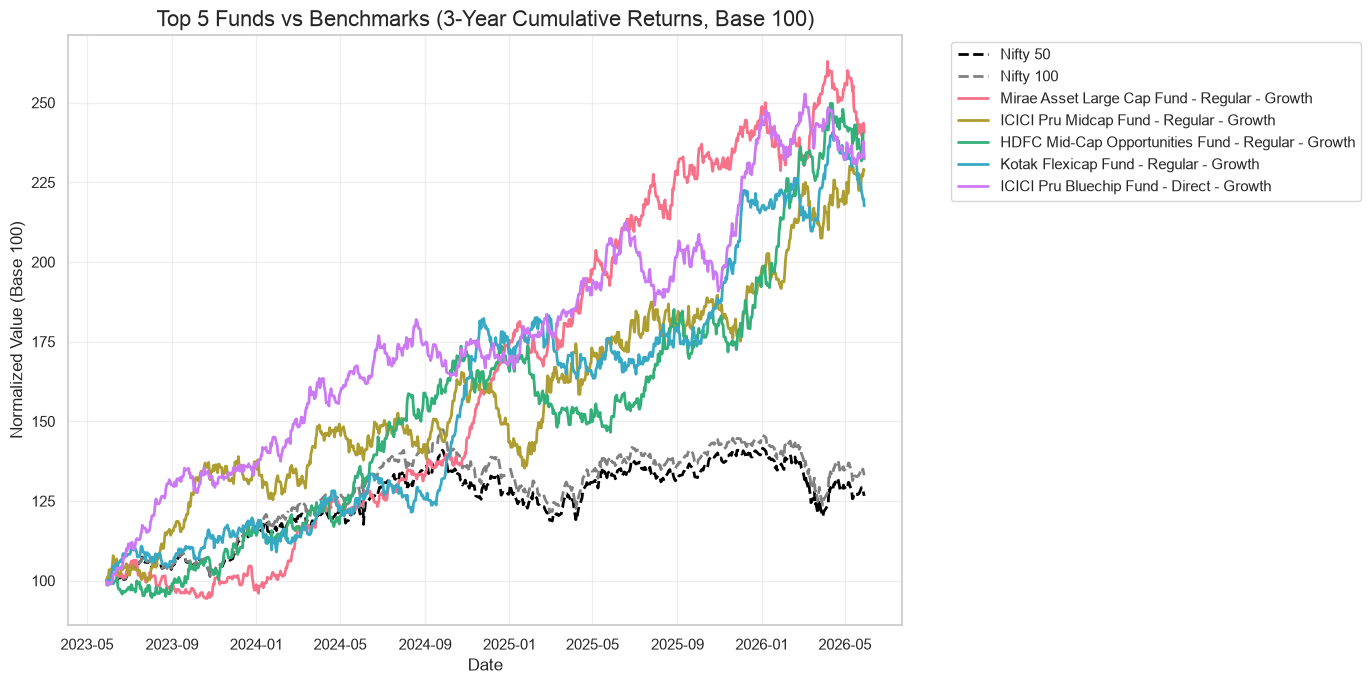

Saved benchmark_comparison.png


In [8]:
print("7. Generating Benchmark Comparison Chart...")
top_5_codes = fund_metrics['amfi_code'].head(5).tolist()

plt.figure(figsize=(14, 7))
chart_start_date = max_date - pd.DateOffset(years=3)

nifty_3yr = nifty_close[nifty_close.index >= chart_start_date].copy()
nifty_3yr['Nifty 50'] = (nifty_3yr['^NSEI'] / nifty_3yr['^NSEI'].iloc[0]) * 100
nifty_3yr['Nifty 100'] = (nifty_3yr['^CNX100'] / nifty_3yr['^CNX100'].iloc[0]) * 100

plt.plot(nifty_3yr.index, nifty_3yr['Nifty 50'], label='Nifty 50', color='black', linewidth=2, linestyle='--')
plt.plot(nifty_3yr.index, nifty_3yr['Nifty 100'], label='Nifty 100', color='gray', linewidth=2, linestyle='--')

colors = sns.color_palette("husl", 5)
for i, code in enumerate(top_5_codes):
    fund_name = fund_metrics[fund_metrics['amfi_code'] == code]['scheme_name'].values[0]
    f_data = fact_nav[(fact_nav['amfi_code'] == code) & (fact_nav['date'] >= chart_start_date)].copy()
    if len(f_data) > 0:
        f_data = f_data.sort_values('date')
        f_data['normalized'] = (f_data['nav'] / f_data['nav'].iloc[0]) * 100
        plt.plot(f_data['date'], f_data['normalized'], label=f"{fund_name}", color=colors[i], linewidth=2)

plt.title('Top 5 Funds vs Benchmarks (3-Year Cumulative Returns, Base 100)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Value (Base 100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=300)
plt.show()
print("Saved benchmark_comparison.png")